# BO Forge minimisation qLogEI campaign

This notebook demonstrates the v0.2 `CampaignSession` workflow for a minimisation problem.

It fills the Sobol initial design one experiment at a time, then requests one qLogEI batch and records all batch results before confirming that best-so-far means the lowest user-facing objective value.

## 1. Setup

The example config uses a batch campaign. The session object owns the config, log path, and current campaign DataFrame.

In [1]:
from pathlib import Path
import os
import shutil
import sys

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
mpl_cache = PROJECT_ROOT / ".matplotlib-cache"
mpl_cache.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from bo_forge.session import CampaignSession

In [2]:
config_path = PROJECT_ROOT / "configs" / "simple_2d_minimise.yaml"
seed_log_path = PROJECT_ROOT / "examples" / "simple_2d_minimise_campaign_log.csv"
working_log_path = PROJECT_ROOT / "examples" / "simple_2d_minimise_working_log.csv"
latest_suggestion_path = PROJECT_ROOT / "examples" / "latest_suggestions.csv"

shutil.copyfile(seed_log_path, working_log_path)

campaign = CampaignSession.from_files(config_path=config_path, log_path=working_log_path)

In [3]:
def simulated_defect_rate(row) -> float:
    loading = float(row["catalyst_loading"])
    temperature = float(row["cure_temperature"])
    defect_rate = 0.08 + 2.2 * (loading - 0.38) ** 2
    defect_rate += ((temperature - 128.0) / 38.0) ** 2
    defect_rate += 0.015 * np.sin(9.0 * loading)
    defect_rate += 0.01 * np.cos(temperature / 18.0)
    return float(defect_rate)


def current_log():
    campaign.reload()
    campaign.validate()
    return campaign.df


def request_one_candidate():
    suggestion = campaign.suggest_next(batch_size=1)
    suggestion.to_csv(latest_suggestion_path, index=False)
    campaign.append_suggestions(suggestion)
    return suggestion


def request_batch(batch_size: int):
    suggestions = campaign.suggest_next(batch_size=batch_size)
    suggestions.to_csv(latest_suggestion_path, index=False)
    campaign.append_suggestions(suggestions)
    return suggestions


def enter_simulated_result(suggestion):
    row = suggestion.iloc[0]
    result = simulated_defect_rate(row)
    campaign.mark_observed(str(row["row_id"]), result)
    return result


def enter_simulated_batch_results(suggestions):
    records = []
    for _, row in suggestions.iterrows():
        result = simulated_defect_rate(row)
        campaign.mark_observed(str(row["row_id"]), result)
        records.append(compact_record(row, result))
    return records


def compact_record(row, result):
    return {
        "source": row["source"],
        "iteration": int(row["iteration"]),
        "catalyst_loading": float(row["catalyst_loading"]),
        "cure_temperature": float(row["cure_temperature"]),
        "defect_rate": result,
    }

## 2. Load and summarise the current campaign

The campaign starts from two manually observed experiments. The remaining initial-design points will be suggested one at a time using Sobol. `campaign.next_action()` shows the recommended next notebook step.

In [4]:
campaign.validate()
print("campaign.summary():")
display(campaign.summary())
print("--"*40)
print("campaign.next_action():")
display(campaign.next_action())
print("--"*40)
campaign.df

campaign.summary():


,field,value
0,campaign_name,process_defect_minimisation
1,campaign_status,ready_for_initial_design
2,objective,defect_rate
3,direction,minimize
4,total_rows,2
5,observed_rows,2
6,pending_suggestions,0
7,initial_design_remaining,4
8,next_iteration,1
9,best_row_id,manual_min_000


--------------------------------------------------------------------------------
campaign.next_action():


,campaign_status,action,reason,suggested_call
0,ready_for_initial_design,suggest_initial_design,Observed rows are below initial_design_size; r...,suggestions = campaign.suggest_next(); campaig...


--------------------------------------------------------------------------------


,row_id,iteration,status,source,catalyst_loading,cure_temperature,defect_rate,predicted_mean,predicted_std,acquisition
0,manual_min_000,0,observed,manual,0.15,100,0.761420,,,
1,manual_min_001,0,observed,manual,0.75,160,1.088474,,,


## 3. Fill the Sobol initial design

Each loop below represents one lab iteration: suggest one candidate, run one experiment, enter one result, reload the log.

In [5]:
sobol_records = []
while len(campaign.observed_data()) < campaign.config.bo.initial_design_size:
    suggestion = request_one_candidate()
    result = enter_simulated_result(suggestion)
    df = current_log()
    sobol_records.append(compact_record(suggestion.iloc[0], result))

sobol_df = pd.DataFrame(sobol_records)
assert set(sobol_df["source"]) == {"sobol"}
sobol_df

,source,iteration,catalyst_loading,cure_temperature,defect_rate
0,sobol,1,0.251865,86.864937,1.300574
1,sobol,2,0.741201,160.687559,1.103850
2,sobol,3,0.784070,117.053388,0.542422
3,sobol,4,0.208949,130.694525,0.169273


## 4. Run one qLogEI batch BO round

Once the initial design is complete, the next session suggestion fits the GP and uses qLogEI because this notebook requests a batch.

In [6]:
batch_suggestions = request_batch(campaign.config.bo.batch_size)
bo_records = enter_simulated_batch_results(batch_suggestions)
df = current_log()
bo_df = pd.DataFrame(bo_records)

assert campaign.config.bo.batch_size > 1
assert set(bo_df["source"]) == {"qlog_ei"}

display(batch_suggestions)
bo_df

,row_id,iteration,status,source,catalyst_loading,cure_temperature,defect_rate,predicted_mean,predicted_std,acquisition
0,606e5e58fb604fbab226317ae8f795c7,5,suggested,qlog_ei,0.326008,127.612662,,0.309527,0.255622,-2.21589
1,3a151782e21349f5858cda9d80b82b8c,5,suggested,qlog_ei,0.083835,126.287799,,0.264677,0.262549,-2.21589


,source,iteration,catalyst_loading,cure_temperature,defect_rate
0,qlog_ei,5,0.326008,127.612662,0.096529
1,qlog_ei,5,0.083835,126.287799,0.292707


In [7]:
batch_suggestions = request_batch(campaign.config.bo.batch_size)
bo_records = enter_simulated_batch_results(batch_suggestions)
df = current_log()
bo_df = pd.DataFrame(bo_records)

assert campaign.config.bo.batch_size > 1
assert set(bo_df["source"]) == {"qlog_ei"}

print("batch suggestion:")
display(batch_suggestions)
print("--"*40)

print("bo_df:")
bo_df

batch suggestion:


,row_id,iteration,status,source,catalyst_loading,cure_temperature,defect_rate,predicted_mean,predicted_std,acquisition
0,b764ef623bf44b22b0e561e8f9adfd3a,6,suggested,qlog_ei,0.350250,122.701811,,0.107892,0.055782,-3.617868
1,98b3cfe8343e4fe3a34387d59f118b18,6,suggested,qlog_ei,0.435827,131.040837,,0.137912,0.068052,-3.617868


--------------------------------------------------------------------------------
bo_df:


,source,iteration,catalyst_loading,cure_temperature,defect_rate
0,qlog_ei,6,0.350250,122.701811,0.109837
1,qlog_ei,6,0.435827,131.040837,0.088131


In [8]:
batch_suggestions = request_batch(campaign.config.bo.batch_size)
bo_records = enter_simulated_batch_results(batch_suggestions)
df = current_log()
bo_df = pd.DataFrame(bo_records)

assert campaign.config.bo.batch_size > 1
assert set(bo_df["source"]) == {"qlog_ei"}

print("batch suggestion:")
display(batch_suggestions)
print("--"*40)

print("bo_df:")
bo_df

batch suggestion:


,row_id,iteration,status,source,catalyst_loading,cure_temperature,defect_rate,predicted_mean,predicted_std,acquisition
0,3769a9cca683497b9a3e90fb618227f6,7,suggested,qlog_ei,0.399226,127.890585,,0.079969,0.014988,-4.518014
1,c613aa492a11441e974b5552135545f9,7,suggested,qlog_ei,0.137938,119.917747,,0.258899,0.031306,-4.518014


--------------------------------------------------------------------------------
bo_df:


,source,iteration,catalyst_loading,cure_temperature,defect_rate
0,qlog_ei,7,0.399226,127.890585,0.081086
1,qlog_ei,7,0.137938,119.917747,0.277629


## 5. Confirm the minimisation best

For a minimisation campaign, the best observation is the lowest user-facing objective value.

In [9]:
df = current_log()
observed = campaign.observed_data()
values = pd.to_numeric(observed[campaign.config.objective.name])
best_index = values.idxmin()
best_row = observed.loc[
    [best_index],
    ["row_id", *campaign.config.variable_names, campaign.config.objective.name],
]

print(f"Objective direction: {campaign.config.objective.direction}")
print(f"Best means lowest {campaign.config.objective.name}: {values.min():.6f}")
display(best_row)

assert campaign.config.objective.direction == "minimize"
assert values.min() == values.cummin().iloc[-1]

Objective direction: minimize
Best means lowest defect_rate: 0.081086


,row_id,catalyst_loading,cure_temperature,defect_rate
10,3769a9cca683497b9a3e90fb618227f6,0.399226,127.890585,0.081086


## 6. Diagnostics

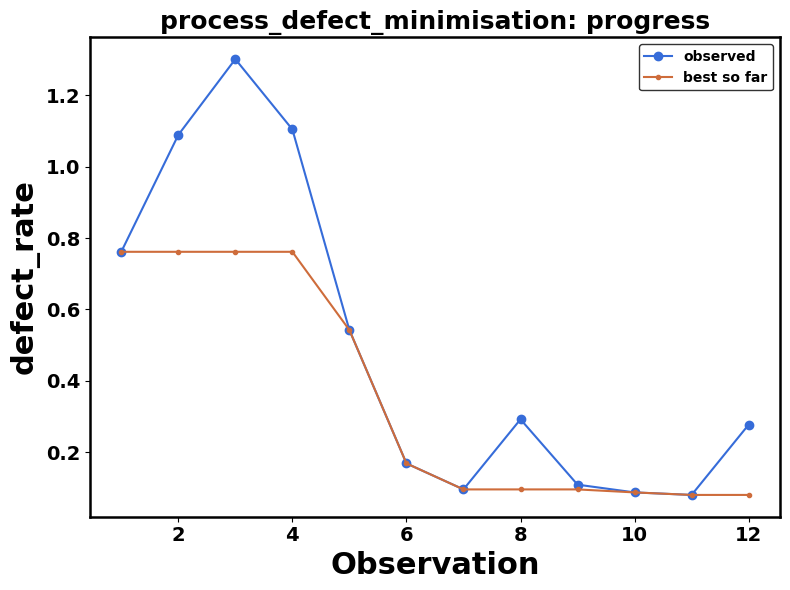

In [10]:
campaign.plot_progress();

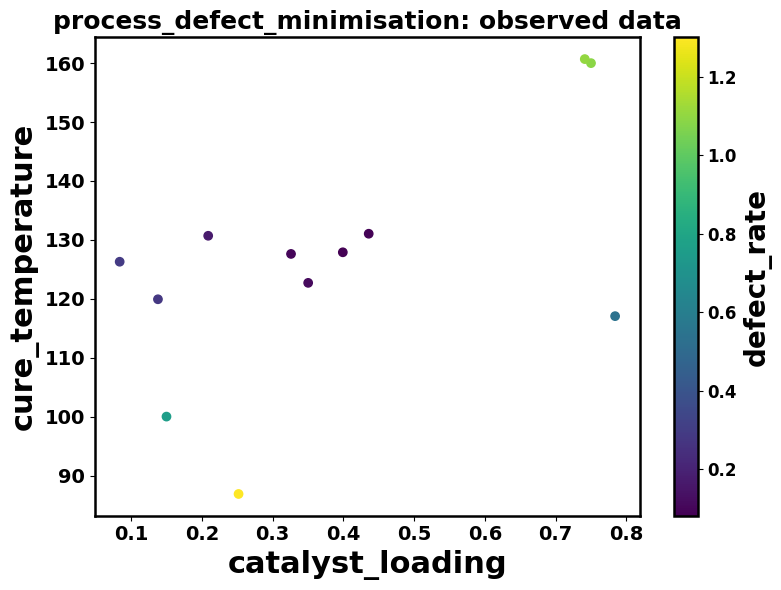

In [11]:
campaign.plot_diagnostics();